# Step 1: Import Libraries & Load Data

In [2]:
# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Data wrangling & preprocessing
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

# Machine learning tools
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb

print("Libraries imported successfully.")



Libraries imported successfully.


# Step 2: Load Dataset & Display First Few Rows

In [3]:
# Load dataset
df = pd.read_csv('Dataset Heart Disease.csv')  # Update with actual dataset path
# Remove the 'Unnamed: 0' column (likely the index column)
df = df.drop(columns=['Unnamed: 0'])
# Display first 5 rows
df.head()


FileNotFoundError: [Errno 2] No such file or directory: 'Dataset Heart Disease.csv'

# Step 3: Data Preprocessing & Heatmap

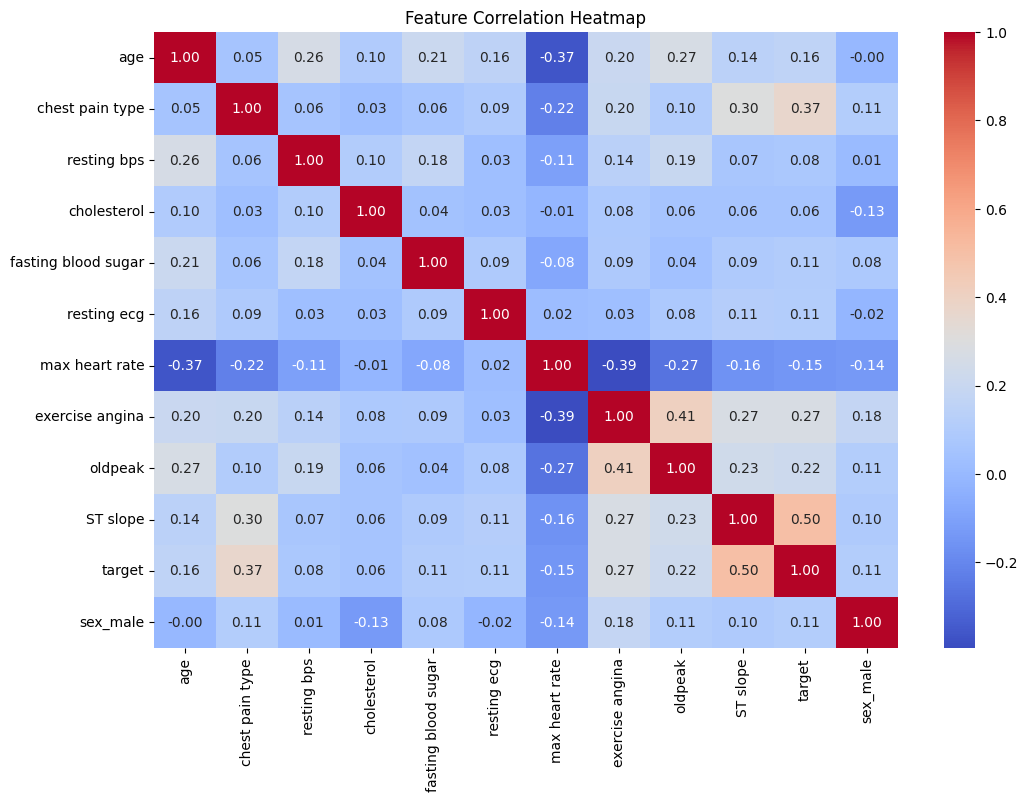

In [ ]:
# Ensure column names are clean
df.columns = df.columns.str.strip()

# Fill missing values with median
df.fillna(df.median(), inplace=True)

# Encode categorical variables
df["sex"] = df["sex"].map({1: "male", 0: "female"})

# Convert categorical features to numerical
df = pd.get_dummies(df, drop_first=True)

# Heatmap of Feature Correlation
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

In [ ]:
print("Column Names in Dataset:", df.columns.tolist())


Column Names in Dataset: ['age', 'chest pain type', 'resting bps', 'cholesterol', 'fasting blood sugar', 'resting ecg', 'max heart rate', 'exercise angina', 'oldpeak', 'ST slope', 'target', 'sex_male']


# Step 4: Split Data 

In [ ]:
# Split features and target
X = df.drop(columns=["target"])
y = df["target"]

# Split into training & testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")


Training set size: 838 samples
Testing set size: 210 samples


# Step 5 : Train a basic Logistic Regression model (Baseline)

In [ ]:

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Train baseline Logistic Regression model
baseline_lr = LogisticRegression(random_state=42)
baseline_lr.fit(X_train, y_train)

# Make predictions using baseline model
y_pred_baseline = baseline_lr.predict(X_test)

# Evaluate performance
baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
baseline_precision = precision_score(y_test, y_pred_baseline, average='weighted')
baseline_recall = recall_score(y_test, y_pred_baseline, average='weighted')
baseline_f1 = f1_score(y_test, y_pred_baseline, average='weighted')

# Print results
print(f"Baseline Logistic Regression Accuracy: {baseline_accuracy * 100:.2f}%")
print(f"Baseline Logistic Regression Precision: {baseline_precision * 100:.2f}%")
print(f"Baseline Logistic Regression Recall: {baseline_recall * 100:.2f}%")
print(f"Baseline Logistic Regression F1 Score: {baseline_f1 * 100:.2f}%")



Baseline Logistic Regression Accuracy: 75.71%
Baseline Logistic Regression Precision: 75.72%
Baseline Logistic Regression Recall: 75.71%
Baseline Logistic Regression F1 Score: 75.71%


In [ ]:
# Train a basic Random Forest model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Get feature importance
feature_importance = pd.DataFrame({"Feature": X_train.columns, "Importance": rf.feature_importances_})
feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

# Display top features
print("Top 5 Important Features:")
print(feature_importance.head(5))


Top 5 Important Features:
           Feature  Importance
9         ST slope    0.251919
6   max heart rate    0.116537
1  chest pain type    0.115481
8          oldpeak    0.101885
0              age    0.099213


# Step 7: Train Optimized Random Forest

In [ ]:
param_grid = {
    "n_estimators": [400, 600, 800, 1000],
    "max_depth": [30, 50, 70, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 3, 5]
}

random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_grid,
    n_iter=25
    ,
    cv=3,
    scoring="accuracy",
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)

print("Best parameters for Random Forest:", random_search.best_params_)


Best parameters for Random Forest: {'n_estimators': 400, 'min_samples_split': 5, 'min_samples_leaf': 3, 'max_depth': 50}


# Step 8: Train Final Optimized Random Forest

In [ ]:
best_rf = RandomForestClassifier(**random_search.best_params_, random_state=42)
best_rf.fit(X_train, y_train)

# Make predictions
y_pred = best_rf.predict(X_test)
print("Final optimized Random Forest model trained successfully.")

# Evaluate model
accuracy = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f'Final Optimized Random Forest Accuracy: {accuracy * 100:.2f}%')
print(f'Final Optimized Random Forest Precision: {prec * 100:.2f}%')
print(f'Final Optimized Random Forest Recall: {rec * 100:.2f}%')
print(f'Final Optimized Random Forest F1 Score: {f1 * 100:.2f}%')

Final optimized Random Forest model trained successfully.
Final Optimized Random Forest Accuracy: 79.05%
Final Optimized Random Forest Precision: 77.19%
Final Optimized Random Forest Recall: 83.02%
Final Optimized Random Forest F1 Score: 80.00%


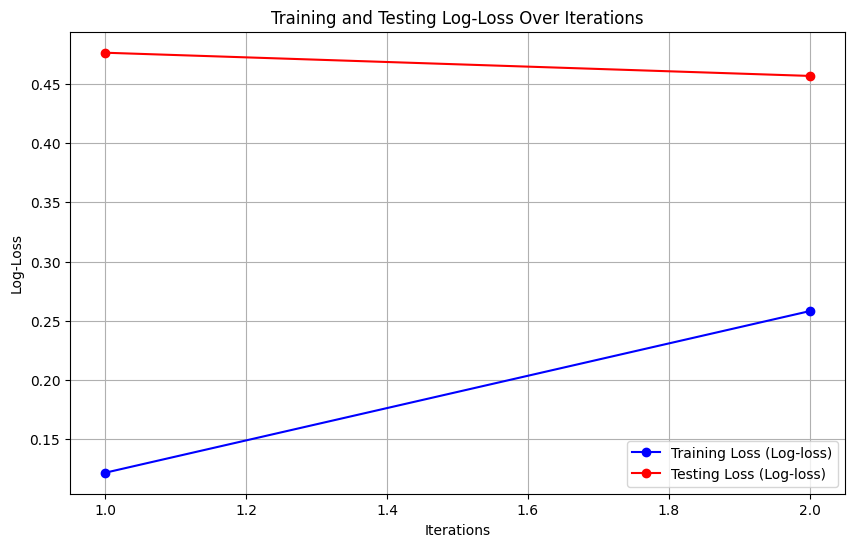

In [ ]:
from sklearn.metrics import log_loss

# Assuming that X_train, y_train, X_test, y_test are already prepared

# List to store the log-loss values for training and testing
train_loss_values = []
test_loss_values = []

# Initially calculate log-loss before optimization
y_train_pred_proba = rf.predict_proba(X_train)
y_test_pred_proba = rf.predict_proba(X_test)

# Calculate the log-loss for training and testing data
train_loss = log_loss(y_train, y_train_pred_proba)
test_loss = log_loss(y_test, y_test_pred_proba)

train_loss_values.append(train_loss)
test_loss_values.append(test_loss)

# If you want to track log-loss over multiple stages of training or hyperparameter tuning
# For example, let's say we optimize the model using RandomizedSearchCV

from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "n_estimators": [400, 600, 800, 1000],
    "max_depth": [30, 50, 70, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 3, 5]
}

random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_grid,
    n_iter=25,
    cv=3,
    scoring="accuracy",
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)

# Get the best model after tuning
best_rf = RandomForestClassifier(**random_search.best_params_, random_state=42)
best_rf.fit(X_train, y_train)

# Calculate log-loss for the optimized model
y_train_pred_proba = best_rf.predict_proba(X_train)
y_test_pred_proba = best_rf.predict_proba(X_test)

train_loss = log_loss(y_train, y_train_pred_proba)
test_loss = log_loss(y_test, y_test_pred_proba)

train_loss_values.append(train_loss)
test_loss_values.append(test_loss)

# Plotting the log-loss graph
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(train_loss_values) + 1), train_loss_values, label="Training Loss (Log-loss)", color='blue', marker='o')
plt.plot(range(1, len(test_loss_values) + 1), test_loss_values, label="Testing Loss (Log-loss)", color='red', marker='o')
plt.title('Training and Testing Log-Loss Over Iterations')
plt.xlabel('Iterations')
plt.ylabel('Log-Loss')
plt.legend()
plt.grid(True)
plt.show()


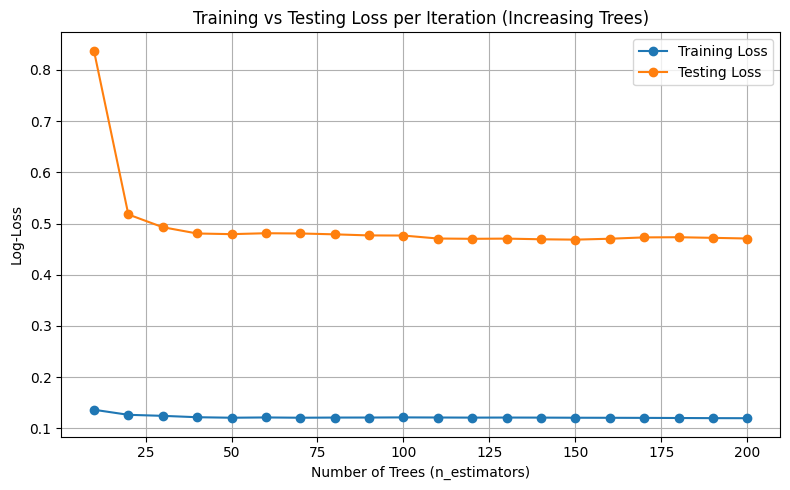

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import log_loss
import matplotlib.pyplot as plt

train_losses = []
test_losses = []
n_estimators_range = range(10, 201, 10)  # From 10 to 200 trees in steps of 10

for n in n_estimators_range:
    rf_iter = RandomForestClassifier(n_estimators=n, random_state=42)
    rf_iter.fit(X_train, y_train)

    y_train_proba = rf_iter.predict_proba(X_train)
    y_test_proba = rf_iter.predict_proba(X_test)

    train_losses.append(log_loss(y_train, y_train_proba))
    test_losses.append(log_loss(y_test, y_test_proba))

# Plotting the losses
plt.figure(figsize=(8, 5))
plt.plot(n_estimators_range, train_losses, label='Training Loss', marker='o')
plt.plot(n_estimators_range, test_losses, label='Testing Loss', marker='o')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('Log-Loss')
plt.title('Training vs Testing Loss per Iteration (Increasing Trees)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Stacking Classifier

In [ ]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import xgboost as xgb

# Train an XGBoost model
xgb_model = xgb.XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=10, random_state=42)
xgb_model.fit(X_train, y_train)

# Define the Stacking Classifier
stacking_model = StackingClassifier(
    estimators=[
        ('rf', best_rf),        # Make sure best_rf is already defined and fitted
        ('xgb', xgb_model)
    ],
    final_estimator=LogisticRegression(),
    n_jobs=-1
)

# Train Stacking Model
stacking_model.fit(X_train, y_train)
print("Stacking Model trained successfully.")

# Predict
y_pred_stack = stacking_model.predict(X_test)

# Evaluate
stacking_accuracy = accuracy_score(y_test, y_pred_stack)
stacking_precision = precision_score(y_test, y_pred_stack, average='weighted')
stacking_recall = recall_score(y_test, y_pred_stack, average='weighted')
stacking_f1 = f1_score(y_test, y_pred_stack, average='weighted')

# Print results
print(f"Stacking Classifier Accuracy: {stacking_accuracy * 100:.2f}%")
print(f"Stacking Classifier Precision: {stacking_precision * 100:.2f}%")
print(f"Stacking Classifier Recall: {stacking_recall * 100:.2f}%")
print(f"Stacking Classifier F1 Score: {stacking_f1 * 100:.2f}%")


Stacking Model trained successfully.
Stacking Classifier Accuracy: 76.67%
Stacking Classifier Precision: 76.68%
Stacking Classifier Recall: 76.67%
Stacking Classifier F1 Score: 76.66%


# Bagging Meta-Estimator with Decision Trees

In [ ]:
# Initialize Bagging Meta-Estimator with Decision Trees
bagging_clf = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=50, random_state=42)
bagging_clf.fit(X_train, y_train)
print("Bagging Meta-Estimator model trained successfully.")
# Make predictions
y_pred_bagging = bagging_clf.predict(X_test)
# Evaluate model
accuracy = accuracy_score(y_test, y_pred_bagging)
prec = precision_score(y_test, y_pred_bagging)
rec = recall_score(y_test, y_pred_bagging)
f1 = f1_score(y_test, y_pred_bagging)

print(f'Bagging Meta-Estimator Accuracy: {accuracy * 100:.2f}%')
print(f'Bagging Meta-Estimator Precision: {prec * 100:.2f}%')
print(f'Bagging Meta-Estimator Recall: {rec * 100:.2f}%')
print(f'Bagging Meta-Estimator F1 Score: {f1 * 100:.2f}%')

Bagging Meta-Estimator model trained successfully.
Bagging Meta-Estimator Accuracy: 75.24%
Bagging Meta-Estimator Precision: 75.47%
Bagging Meta-Estimator Recall: 75.47%
Bagging Meta-Estimator F1 Score: 75.47%


# GaussianNB model

In [ ]:

# Initialize GaussianNB model
gnb = GaussianNB()

# Train the model
gnb.fit(X_train, y_train)
print("Gaussian Naive Bayes model trained successfully.")
# Make predictions
y_pred_gnb = gnb.predict(X_test)

# Evaluate model
accuracy = accuracy_score(y_test, y_pred_gnb)
prec = precision_score(y_test, y_pred_gnb)
rec = recall_score(y_test, y_pred_gnb)
f1 = f1_score(y_test, y_pred_gnb)
print(f'Gaussian Naive Bayes Accuracy: {accuracy * 100:.2f}%')
print(f'Gaussian Naive Bayes Precision: {prec * 100:.2f}%')
print(f'Gaussian Naive Bayes Recall: {rec * 100:.2f}%')
print(f'Gaussian Naive Bayes F1 Score: {f1 * 100:.2f}%')

Gaussian Naive Bayes model trained successfully.
Gaussian Naive Bayes Accuracy: 74.76%
Gaussian Naive Bayes Precision: 76.77%
Gaussian Naive Bayes Recall: 71.70%
Gaussian Naive Bayes F1 Score: 74.15%


# Confusion Matrix for Random Forest

Confusion Matrix for Random Forest:


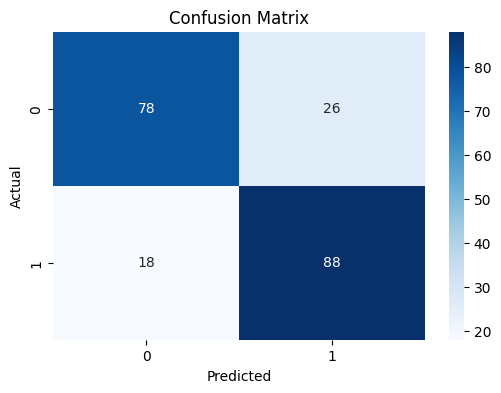

In [ ]:

print("Confusion Matrix for Random Forest:")
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap="Blues", fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Confusion Matrix for Stacking Classifier

Confusion Matrix for Stacking Classifier:


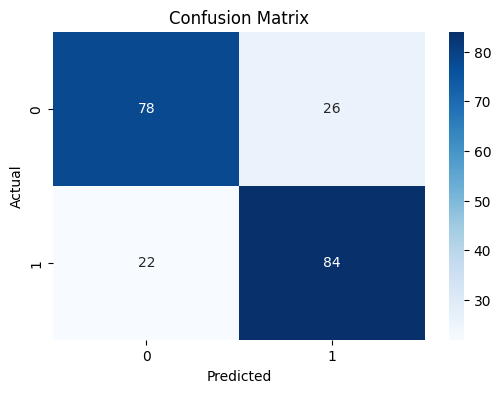

In [ ]:
# Confusion Matrix for Stacking Classifier
print("Confusion Matrix for Stacking Classifier:")
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test,stacking_model.predict(X_test)), annot=True, cmap="Blues", fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Confusion Matrix for Bagging Meta-Estimator

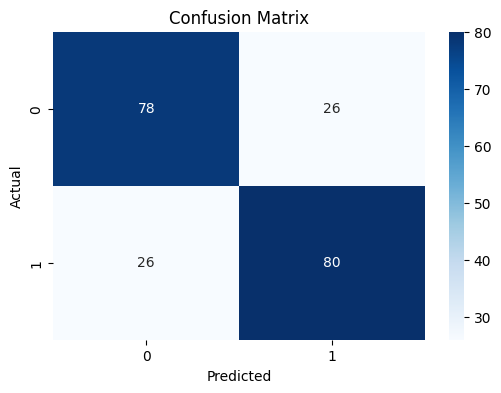

In [ ]:
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_bagging), annot=True, cmap="Blues", fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Confusion Matrix for Gaussian Naive Bayes

Confusion Matrix for Gaussian Naive Bayes:


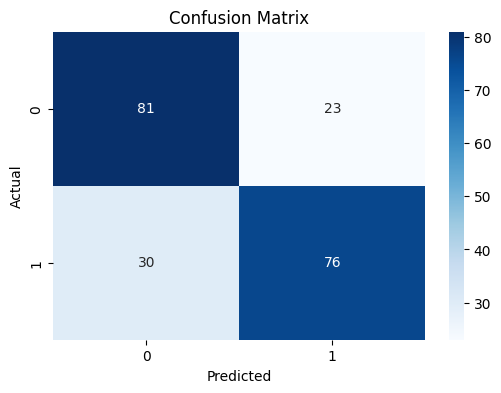

In [ ]:
print("Confusion Matrix for Gaussian Naive Bayes:")
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_gnb), annot=True, cmap="Blues", fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()